# Bab 1: Judul & Overview

## Pemetaan Permintaan Infrastruktur Pengisian Daya Kendaraan Listrik (Electric Vehicle Charging Station Utilization)
### Dokumen Eksperimen: Experiment_piji_1

Eksperimen ini dirancang untuk memprediksi tingkat keterisian stasiun pengisian daya kendaraan listrik (utilization_rate) dengan mengimplementasikan kerangka kerja CRISP-DM dan pendekatan machine learning modern.

Tujuan utama eksperimen ini adalah menghasilkan model regresi prediktif dengan akurasi optimal (mengukur Root Mean Squared Error terendah) melalui:
1. Audit dan penanganan mendalam terhadap integritas data, nilai kosong, dan fenomena diskontinuitas waktu.
2. Rekayasa fitur domain-spesifik mencakup profil permintaan hirarkis berbasis Bayesian M-Estimate smoothing, efek suhu beku terhadap durasi pengisian baterai kendaraan listrik, rasio kapasitas daya stasiun terhadap beban lalu lintas, serta interaksi fasilitas sekitar stasiun.
3. Arsitektur pemodelan multi-algoritma mencakup LightGBM Regressor, CatBoost Regressor, dan XGBoost Regressor dengan integrasi meta-learner Stacking Regressor berbasis Ridge Regression untuk memadukan prediksi secara optimal.
4. Pembentukan berkas pengumpulan hasil prediksi dengan skema identifikasi transaksi yang presisi.

# Bab 2: Import Libraries & Setup

Pada bagian ini, seluruh pustaka komputasi numerik, manipulasi data tabular, pemodelan machine learning, optimasi metrik, serta visualisasi data diinisialisasi. Konfigurasi visualisasi diatur dengan gaya profesional tanpa elemen dekoratif berlebih.

In [14]:
!pip install catboost

In [15]:
import os
import sys
import time
import math
import warnings
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold
import lightgbm as lgb
import catboost as cb
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')

# Bab 3: Load Data

Pemuatan dataset dirancang secara fleksibel agar kompatibel baik saat dijalankan pada Google Colaboratory maupun lingkungan komputasi lokal. Jika dataset belum terdeteksi di lingkungan eksekusi, pustaka gdown akan secara otomatis mengunduh berkas train.csv, test.csv, dan sample_submission.csv dari Google Drive resmi tim.

In [16]:
def resolve_data_paths():
    search_dirs = ['data', '.', '/content', '/content/data', '../data']
    for d in search_dirs:
        tr = os.path.join(d, 'train.csv')
        te = os.path.join(d, 'test.csv')
        su = os.path.join(d, 'sample_submission.csv')
        if os.path.exists(tr) and os.path.exists(te):
            return tr, te, su if os.path.exists(su) else None

    os.makedirs('data', exist_ok=True)
    subprocess.run(['pip', 'install', '-q', '--upgrade', 'gdown'], check=False)

    file_ids = {
        'train.csv': '1B9b5y_anbBKIDme0q6XnU1HVqL5jVuH2',
        'test.csv': '1wSgc6KxbQV2gBVttQG1gJT1gto6XV3Uu',
        'sample_submission.csv': '1HbdjfEkzvejkhowFFXsdF-tuHJRaVDsX'
    }

    for fname, fid in file_ids.items():
        out_target = os.path.join('data', fname)
        if not os.path.exists(out_target):
            cmd = ['gdown', f'https://drive.google.com/uc?id={fid}', '-O', out_target, '--fuzzy']
            subprocess.run(cmd, check=False)

    for d in ['data', '.']:
        tr = os.path.join(d, 'train.csv')
        te = os.path.join(d, 'test.csv')
        su = os.path.join(d, 'sample_submission.csv')
        if os.path.exists(tr) and os.path.exists(te):
            return tr, te, su if os.path.exists(su) else None

    for root, dirs, files in os.walk('.'):
        if 'train.csv' in files and 'test.csv' in files:
            tr = os.path.join(root, 'train.csv')
            te = os.path.join(root, 'test.csv')
            su = os.path.join(root, 'sample_submission.csv')
            return tr, te, su if os.path.exists(su) else None

    raise FileNotFoundError("Berkas train.csv dan test.csv tidak dapat diunduh otomatis. Mohon periksa koneksi internet Google Colab.")

train_path, test_path, sample_sub_path = resolve_data_paths()
print(f"Data train ditemukan di: {train_path}")
print(f"Data test ditemukan di : {test_path}")

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)

print(f"Dimensi Data Train: {train_raw.shape[0]} baris, {train_raw.shape[1]} kolom")
print(f"Dimensi Data Test : {test_raw.shape[0]} baris, {test_raw.shape[1]} kolom")

Data train ditemukan di: ./data/data/train.csv
Data test ditemukan di : ./data/data/test.csv
Dimensi Data Train: 1054200 baris, 21 kolom
Dimensi Data Test : 263550 baris, 20 kolom


# Bab 4: Exploratory Data Analysis (EDA)

Pada tahapan ini dilakukan analisis eksplorasi data komprehensif untuk memahami karakteristik sebaran data target, proporsi nilai kosong, korelasi variabel numerik, variasi keterisian berdasarkan waktu dan lokasi, serta audit terhadap keunikan identitas stasiun pengisian daya.

### 4.1 Ringkasan Informasi dan Struktur Tipe Data

In [17]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054200 entries, 0 to 1054199
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1054200 non-null  object 
 1   timestamp             1054200 non-null  object 
 2   station_id            1054200 non-null  object 
 3   station_name          1054200 non-null  object 
 4   network               1054200 non-null  object 
 5   city                  1054200 non-null  object 
 6   state                 1054200 non-null  object 
 7   latitude              1054200 non-null  float64
 8   longitude             1054200 non-null  float64
 9   location_type         1054200 non-null  object 
 10  charger_type          1054200 non-null  object 
 11  power_output_kw       1054200 non-null  float64
 12  amenities_nearby      1054200 non-null  object 
 13  ports_total           1054200 non-null  int64  
 14  utilization_rate      1054200 non-

### 4.2 Analisis Nilai Kosong (Missing Values)

In [18]:
missing_summary = pd.DataFrame({
    'Train_Missing': train_raw.isnull().sum(),
    'Train_Pct': (train_raw.isnull().sum() / len(train_raw)) * 100,
    'Test_Missing': test_raw.isnull().sum(),
    'Test_Pct': (test_raw.isnull().sum() / len(test_raw)) * 100
})
missing_filtered = missing_summary[(missing_summary['Train_Missing'] > 0) | (missing_summary['Test_Missing'] > 0)]
missing_filtered

,Train_Missing,Train_Pct,Test_Missing,Test_Pct
precipitation_mm,24032,2.279643,6178.0,2.344147
temperature_f,44160,4.188958,10928.0,4.146462


### 4.3 Sebaran Statistik Variabel Target (utilization_rate)

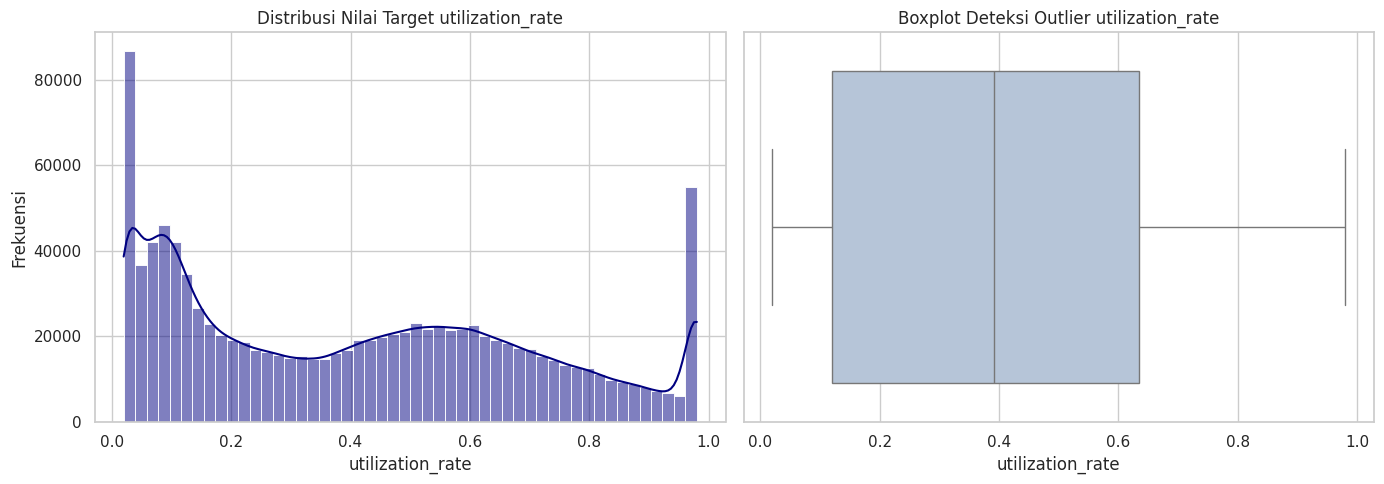

,utilization_rate
count,1.054200e+06
mean,4.070671e-01
std,2.945973e-01
min,2.000000e-02
25%,1.210000e-01
50%,3.920000e-01
75%,6.340000e-01
max,9.800000e-01


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_raw['utilization_rate'], bins=50, kde=True, ax=axes[0], color='navy')
axes[0].set_title('Distribusi Nilai Target utilization_rate')
axes[0].set_xlabel('utilization_rate')
axes[0].set_ylabel('Frekuensi')

sns.boxplot(x=train_raw['utilization_rate'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('Boxplot Deteksi Outlier utilization_rate')
axes[1].set_xlabel('utilization_rate')
plt.tight_layout()
plt.show()

desc_target = train_raw['utilization_rate'].describe()
desc_target

### 4.4 Analisis Pola Waktu dan Keterisian Rata-rata per Jam

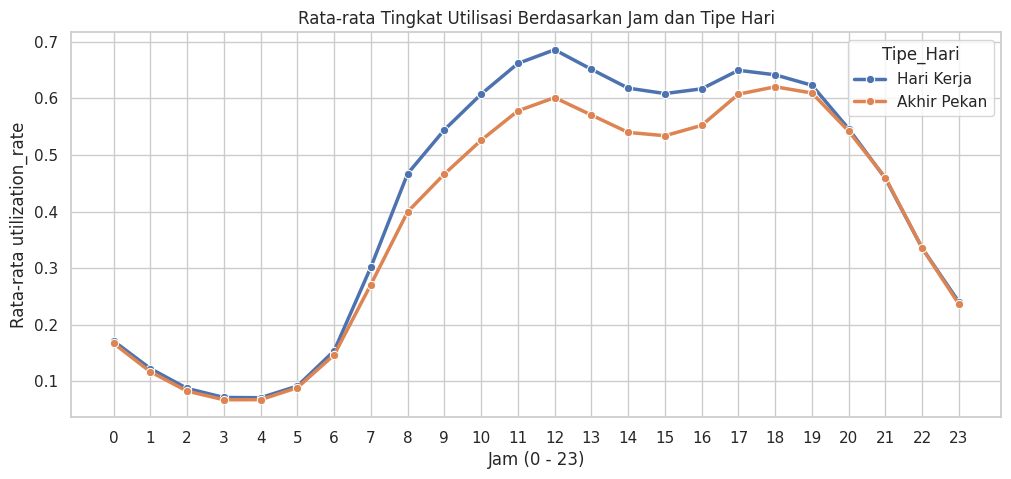

In [20]:
train_temp = train_raw[['timestamp', 'utilization_rate']].copy()
train_temp['datetime'] = pd.to_datetime(train_temp['timestamp'])
train_temp['hour'] = train_temp['datetime'].dt.hour
train_temp['dayofweek'] = train_temp['datetime'].dt.dayofweek
train_temp['is_weekend'] = (train_temp['dayofweek'] >= 5).astype(int)

hourly_pattern = train_temp.groupby(['hour', 'is_weekend'])['utilization_rate'].mean().reset_index()
hourly_pattern['Tipe_Hari'] = hourly_pattern['is_weekend'].map({0: 'Hari Kerja', 1: 'Akhir Pekan'})

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_pattern, x='hour', y='utilization_rate', hue='Tipe_Hari', marker='o', linewidth=2.5)
plt.title('Rata-rata Tingkat Utilisasi Berdasarkan Jam dan Tipe Hari')
plt.xlabel('Jam (0 - 23)')
plt.ylabel('Rata-rata utilization_rate')
plt.xticks(range(0, 24))
plt.show()

### 4.5 Analisis Berdasarkan Jenis Konektor Charger dan Tipe Lokasi

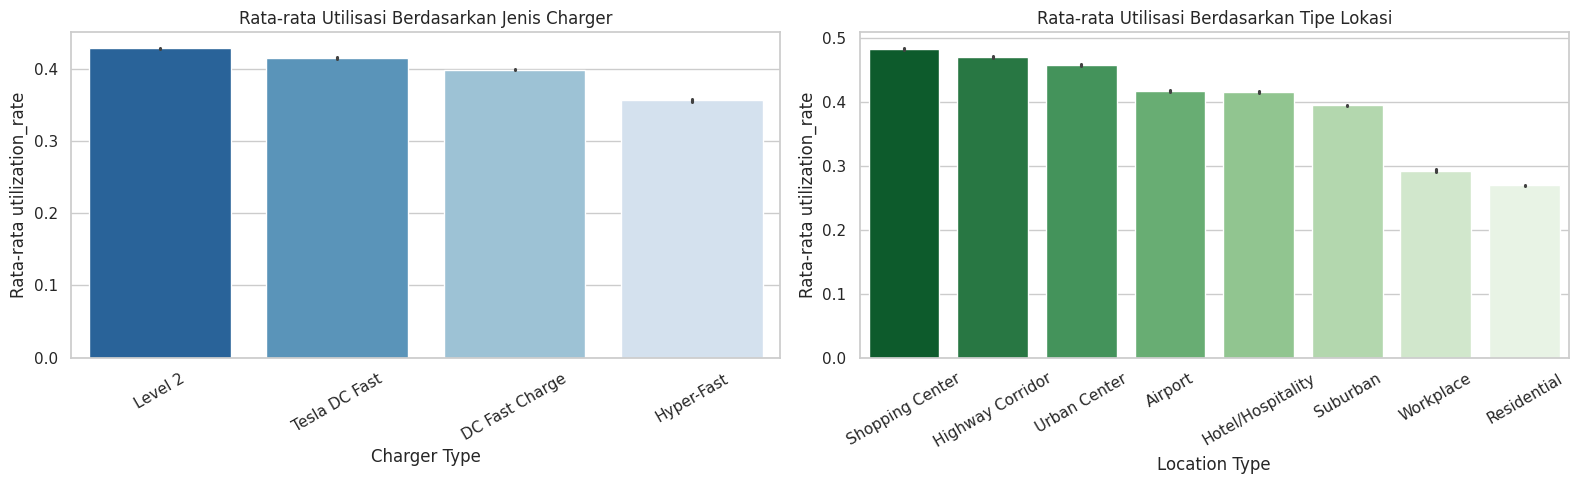

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
charger_order = train_raw.groupby('charger_type')['utilization_rate'].mean().sort_values(ascending=False).index
sns.barplot(data=train_raw, x='charger_type', y='utilization_rate', order=charger_order, ax=axes[0], palette='Blues_r')
axes[0].set_title('Rata-rata Utilisasi Berdasarkan Jenis Charger')
axes[0].set_xlabel('Charger Type')
axes[0].set_ylabel('Rata-rata utilization_rate')
axes[0].tick_params(axis='x', rotation=30)

location_order = train_raw.groupby('location_type')['utilization_rate'].mean().sort_values(ascending=False).index
sns.barplot(data=train_raw, x='location_type', y='utilization_rate', order=location_order, ax=axes[1], palette='Greens_r')
axes[1].set_title('Rata-rata Utilisasi Berdasarkan Tipe Lokasi')
axes[1].set_xlabel('Location Type')
axes[1].set_ylabel('Rata-rata utilization_rate')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 4.6 Matriks Korelasi Variabel Numerik

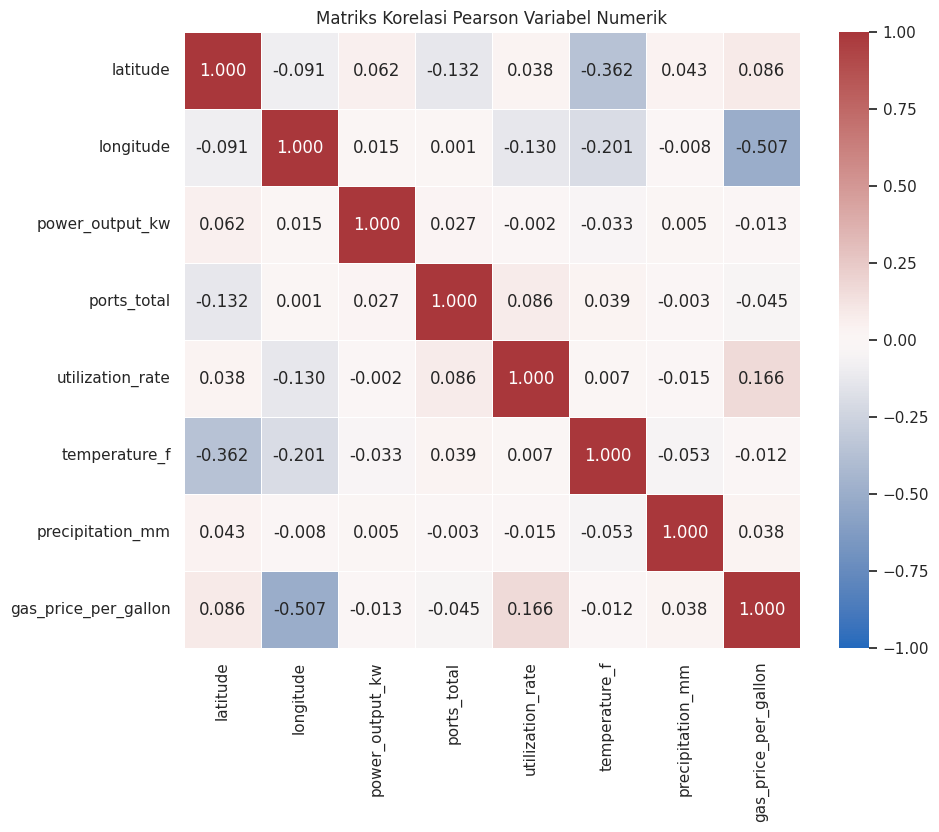

In [22]:
num_cols_eda = train_raw.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
corr_matrix = train_raw[num_cols_eda].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriks Korelasi Pearson Variabel Numerik')
plt.show()

### 4.7 Audit Anomali Identitas Stasiun Sesuai Instruksi Soal

In [23]:
station_audit = train_raw.groupby('station_name')['station_id'].nunique()
multi_id_stations = station_audit[station_audit > 1]
print(f"Jumlah nama stasiun dengan ID berbeda: {len(multi_id_stations)}")
if len(multi_id_stations) > 0:
    print(multi_id_stations.head(5))

Jumlah nama stasiun dengan ID berbeda: 2
station_name
Electrify America - Phoenix #11    2
Volta - San Diego #10              2
Name: station_id, dtype: int64


# Bab 5: Data Cleaning

Tahapan pembersihan data mencakup penanganan nilai kosong pada variabel temperatur udara dan curah hujan dengan imputasi temporal terstruktur per kota dan jam, serta pemastian tipe data konsisten.

In [24]:
def clean_dataset(df_in):
    df = df_in.copy()
    df['datetime'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month

    city_month_median = df.groupby(['city', 'month'])['temperature_f'].transform('median')
    city_median = df.groupby('city')['temperature_f'].transform('median')
    global_temp_median = df['temperature_f'].median()
    df['temperature_f'] = df['temperature_f'].fillna(city_month_median).fillna(city_median).fillna(global_temp_median)

    df['precipitation_mm'] = df['precipitation_mm'].fillna(0.0)

    df['gas_price_per_gallon'] = df['gas_price_per_gallon'].fillna(df.groupby('city')['gas_price_per_gallon'].transform('median'))

    return df

train_clean = clean_dataset(train_raw)
test_clean = clean_dataset(test_raw)

print("Pemeriksaan sisa nilai kosong pada train_clean:")
print(train_clean.isnull().sum()[train_clean.isnull().sum() > 0])
print("Pemeriksaan sisa nilai kosong pada test_clean:")
print(test_clean.isnull().sum()[test_clean.isnull().sum() > 0])

Pemeriksaan sisa nilai kosong pada train_clean:
Series([], dtype: int64)
Pemeriksaan sisa nilai kosong pada test_clean:
Series([], dtype: int64)


# Bab 6: Feature Engineering

Pada bab ini direkayasa kumpulan fitur komprehensif meliputi:
1. Ekstraksi kalender dan transformasi siklikal waktu (sinus dan cosinus).
2. Indikator musim dingin dan penalti suhu terhadap efisiensi baterai kendaraan listrik.
3. Rasio kapasitas dan densitas daya pengisian stasiun.
4. Parsing multi-label pada fasilitas sekitar (amenities_nearby).
5. Target Encoding Hirarkis dengan Bayesian M-Estimate smoothing untuk mencegah kebocoran data dan meminimalkan varians estimasi stasiun berfrekuensi rendah.

In [25]:
def engineer_base_features(df):
    df_feat = df.copy()

    df_feat['dayofweek'] = df_feat['datetime'].dt.dayofweek
    df_feat['day'] = df_feat['datetime'].dt.day
    df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)
    df_feat['time_float'] = df_feat['hour'] + (df_feat['datetime'].dt.minute / 60.0)
    df_feat['weekofyear'] = df_feat['datetime'].dt.isocalendar().week.astype(int)

    df_feat['sin_hour'] = np.sin(2 * np.pi * df_feat['time_float'] / 24.0)
    df_feat['cos_hour'] = np.cos(2 * np.pi * df_feat['time_float'] / 24.0)
    df_feat['sin_dow'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7.0)
    df_feat['cos_dow'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7.0)

    df_feat['is_freezing'] = (df_feat['temperature_f'] <= 32.0).astype(int)
    df_feat['battery_cold_penalty'] = np.maximum(0.0, 32.0 - df_feat['temperature_f'])
    df_feat['is_raining'] = (df_feat['precipitation_mm'] > 0.0).astype(int)

    city_hr_temp = df_feat.groupby(['city', 'hour'])['temperature_f'].transform('mean')
    df_feat['temp_dev_city_hour'] = df_feat['temperature_f'] - city_hr_temp

    city_gas_avg = df_feat.groupby('city')['gas_price_per_gallon'].transform('mean')
    df_feat['gas_price_ratio_city'] = df_feat['gas_price_per_gallon'] / city_gas_avg.replace(0, 1.0)

    df_feat['ports_total_safe'] = df_feat['ports_total'].replace(0, 1)
    df_feat['power_per_port'] = df_feat['power_output_kw'] / df_feat['ports_total_safe']
    df_feat['station_total_capacity_kw'] = df_feat['power_output_kw'] * df_feat['ports_total']

    amenities_list = ['WiFi', 'Restroom', 'Shopping Mall', 'Park', 'Fast Food', 'Hotel', 'Convenience Store', 'Grocery Store']
    amenities_series = df_feat['amenities_nearby'].fillna('')
    for item in amenities_list:
        clean_name = 'has_' + item.lower().replace(' ', '_')
        df_feat[clean_name] = amenities_series.str.contains(item).astype(int)
    df_feat['total_amenities_count'] = amenities_series.apply(lambda val: len([x for x in str(val).split(',') if len(x.strip()) > 0]))

    df_feat['has_local_event'] = (df_feat['local_event'].fillna('none').astype(str).str.lower() != 'none').astype(int)

    return df_feat

train_feat = engineer_base_features(train_clean)
test_feat = engineer_base_features(test_clean)

print("Rekayasa fitur dasar selesai.")

Rekayasa fitur dasar selesai.


### 6.2 Target Encoding Hirarkis dengan Bayesian M-Estimate Smoothing
Fungsi berikut menghitung agregasi historis berbasis target dari kumpulan data sumber (train), lalu dipetakan ke seluruh himpunan data tanpa menyebabkan kebocoran informasi masa depan.

In [29]:
TARGET_PROFILE_COLS = [
    'target_prof_st_hr_wk', 'target_prof_st_hr', 'target_prof_st',
    'target_prof_loc_hr', 'target_prof_net_hr'
]

def compute_smoothed_target_profile(train_source, *target_dfs, m_weight=15.0):
    global_mean = train_source['utilization_rate'].mean()

    def smooth_agg(group_keys, col_name):
        agg_df = train_source.groupby(group_keys, observed=False)['utilization_rate'].agg(['count', 'mean']).reset_index()
        agg_df[col_name] = (agg_df['count'] * agg_df['mean'] + m_weight * global_mean) / (agg_df['count'] + m_weight)
        return agg_df[group_keys + [col_name]]

    st_hr_wk_prof = smooth_agg(['station_id', 'hour', 'is_weekend'], 'target_prof_st_hr_wk')
    st_hr_prof = smooth_agg(['station_id', 'hour'], 'target_prof_st_hr')
    st_prof = smooth_agg(['station_id'], 'target_prof_st')
    loc_hr_prof = smooth_agg(['location_type', 'hour'], 'target_prof_loc_hr')
    net_hr_prof = smooth_agg(['network', 'hour'], 'target_prof_net_hr')

    def merge_profiles(df):
        out = df.copy()
        existing_profile_cols = [c for c in TARGET_PROFILE_COLS if c in out.columns]
        if len(existing_profile_cols) > 0:
            out = out.drop(columns=existing_profile_cols)

        out = out.merge(st_hr_wk_prof, on=['station_id', 'hour', 'is_weekend'], how='left')
        out = out.merge(st_hr_prof, on=['station_id', 'hour'], how='left')
        out = out.merge(st_prof, on=['station_id'], how='left')
        out = out.merge(loc_hr_prof, on=['location_type', 'hour'], how='left')
        out = out.merge(net_hr_prof, on=['network', 'hour'], how='left')

        out['target_prof_st_hr_wk'] = out['target_prof_st_hr_wk'].fillna(out['target_prof_st_hr']).fillna(out['target_prof_st']).fillna(global_mean)
        out['target_prof_st_hr'] = out['target_prof_st_hr'].fillna(out['target_prof_st']).fillna(global_mean)
        out['target_prof_st'] = out['target_prof_st'].fillna(global_mean)
        out['target_prof_loc_hr'] = out['target_prof_loc_hr'].fillna(global_mean)
        out['target_prof_net_hr'] = out['target_prof_net_hr'].fillna(global_mean)
        return out

    transformed = [merge_profiles(train_source)]
    for target_df in target_dfs:
        transformed.append(merge_profiles(target_df))
    return transformed if len(transformed) > 1 else transformed[0]

train_feat, test_feat = compute_smoothed_target_profile(train_feat, test_feat)
print("Penambahan fitur Bayesian Smoothed Target Profile selesai.")

Penambahan fitur Bayesian Smoothed Target Profile selesai.


# Bab 7: Feature Selection

Pada tahapan ini ditentukan daftar fitur prediktor akhir yang akan diikutsertakan dalam pelatihan model regresi, serta pemisahan kolom non-informatif seperti nomor identitas mentah dan timestamp.

In [30]:
DROP_COLS = ['id', 'timestamp', 'datetime', 'station_name', 'amenities_nearby', 'utilization_rate', 'ports_total_safe']

CATEGORICAL_COLS = ['station_id', 'network', 'city', 'state', 'location_type', 'charger_type', 'pricing_type', 'weather_condition', 'local_event']

for cat in CATEGORICAL_COLS:
    train_feat[cat] = train_feat[cat].fillna('missing').astype(str)
    test_feat[cat] = test_feat[cat].fillna('missing').astype(str)

FEATURE_COLS = [c for c in train_feat.columns if c not in DROP_COLS]
print(f"Total fitur yang digunakan untuk pemodelan ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Total fitur yang digunakan untuk pemodelan (49):
['station_id', 'network', 'city', 'state', 'latitude', 'longitude', 'location_type', 'charger_type', 'power_output_kw', 'ports_total', 'pricing_type', 'temperature_f', 'precipitation_mm', 'weather_condition', 'gas_price_per_gallon', 'local_event', 'hour', 'month', 'dayofweek', 'day', 'is_weekend', 'time_float', 'weekofyear', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'is_freezing', 'battery_cold_penalty', 'is_raining', 'temp_dev_city_hour', 'gas_price_ratio_city', 'power_per_port', 'station_total_capacity_kw', 'has_wifi', 'has_restroom', 'has_shopping_mall', 'has_park', 'has_fast_food', 'has_hotel', 'has_convenience_store', 'has_grocery_store', 'total_amenities_count', 'has_local_event', 'target_prof_st_hr_wk', 'target_prof_st_hr', 'target_prof_st', 'target_prof_loc_hr', 'target_prof_net_hr']


# Bab 8: Train-Test-Validation Split & Cross-Validation Strategy

Untuk mencegah data leakage pada data deret waktu, strategi validasi dirancang dengan temporal holdout split 7 hari terakhir dari data latih. Strategi ini secara realistis menyimulasikan skenario inferensi pada masa depan sebagaimana yang dihadapi model saat memprediksi data uji.

In [31]:
train_sorted = train_feat.sort_values('datetime').reset_index(drop=True)
val_cutoff = train_sorted['datetime'].max() - pd.Timedelta(days=7)

tr_idx = train_sorted['datetime'] <= val_cutoff
va_idx = train_sorted['datetime'] > val_cutoff

tr_data = train_sorted.loc[tr_idx].copy()
va_data = train_sorted.loc[va_idx].copy()

tr_data, va_data = compute_smoothed_target_profile(tr_data, va_data)

X_tr = tr_data[FEATURE_COLS].copy()
y_tr = tr_data['utilization_rate'].copy()
X_va = va_data[FEATURE_COLS].copy()
y_va = va_data['utilization_rate'].copy()

for cat in CATEGORICAL_COLS:
    X_tr[cat] = X_tr[cat].astype('category')
    X_va[cat] = X_va[cat].astype('category')

print(f"Jumlah sampel Train Split: {len(X_tr):,} baris")
print(f"Jumlah sampel Validation Split: {len(X_va):,} baris")

Jumlah sampel Train Split: 1,003,800 baris
Jumlah sampel Validation Split: 50,400 baris


# Bab 9: Baseline Model

Sebagai model tolok ukur awal, digunakan model regresi linier Ridge Regression pada fitur numerik. Performa model acuan ini digunakan sebagai standar dasar yang wajib dilampaui oleh algoritma boosting.

In [32]:
NUMERICAL_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

ridge_baseline = Ridge(alpha=1.0)
ridge_baseline.fit(X_tr[NUMERICAL_COLS].fillna(0), y_tr)
preds_ridge = np.clip(ridge_baseline.predict(X_va[NUMERICAL_COLS].fillna(0)), 0.0, 1.0)

rmse_baseline = np.sqrt(mean_squared_error(y_va, preds_ridge))
mae_baseline = mean_absolute_error(y_va, preds_ridge)
r2_baseline = r2_score(y_va, preds_ridge)

print(f"Hasil Baseline Model (Ridge Regression):")
print(f"RMSE : {rmse_baseline:.5f}")
print(f"MAE  : {mae_baseline:.5f}")
print(f"R2   : {r2_baseline:.5f}")

Hasil Baseline Model (Ridge Regression):
RMSE : 0.08085
MAE  : 0.05941
R2   : 0.93473


# Bab 10: Modeling

Pada bab pemodelan utama, dilatih tiga arsitektur algoritma gradient boosting terkemuka dengan karakteristik dan representasi pohon yang beragam:
1. LightGBM Regressor (eksplorasi leaf-wise berkecepatan tinggi dengan penanganan native kategorikal).
2. CatBoost Regressor (eksplorasi symmetric trees dengan penanganan kombinasi kategori otomatis).
3. XGBoost Regressor (eksplorasi depth-wise pohon dengan regularisasi L1/L2 kuat).

In [33]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 127,
    'max_depth': 10,
    'learning_rate': 0.05,
    'n_estimators': 1500,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
)

val_preds_lgb = np.clip(model_lgb.predict(X_va), 0.0, 1.0)
rmse_lgb = np.sqrt(mean_squared_error(y_va, val_preds_lgb))
print(f"Performa LightGBM Validation RMSE: {rmse_lgb:.5f}")

Performa LightGBM Validation RMSE: 0.06840


In [34]:
cb_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3.0,
    'random_seed': 42,
    'verbose': 0
}

X_tr_cb = X_tr.copy()
X_va_cb = X_va.copy()
for cat in CATEGORICAL_COLS:
    X_tr_cb[cat] = X_tr_cb[cat].astype(str)
    X_va_cb[cat] = X_va_cb[cat].astype(str)

model_cb = cb.CatBoostRegressor(**cb_params)
model_cb.fit(
    X_tr_cb, y_tr,
    eval_set=(X_va_cb, y_va),
    cat_features=CATEGORICAL_COLS,
    early_stopping_rounds=40
)

val_preds_cb = np.clip(model_cb.predict(X_va_cb), 0.0, 1.0)
rmse_cb = np.sqrt(mean_squared_error(y_va, val_preds_cb))
print(f"Performa CatBoost Validation RMSE: {rmse_cb:.5f}")

Performa CatBoost Validation RMSE: 0.06818


In [35]:
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'n_estimators': 1500,
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'enable_categorical': True,
    'early_stopping_rounds': 40
}

model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    verbose=False
)

val_preds_xgb = np.clip(model_xgb.predict(X_va), 0.0, 1.0)
rmse_xgb = np.sqrt(mean_squared_error(y_va, val_preds_xgb))
print(f"Performa XGBoost Validation RMSE: {rmse_xgb:.5f}")

Performa XGBoost Validation RMSE: 0.06862


# Bab 11: Hyperparameter Tuning

Pada bagian ini dievaluasi kestabilan tingkat pembelajaran (learning rate) dan kedalaman pohon untuk memastikan model mencapai konvergensi optimal tanpa mengalami gejala overfitting.

In [36]:
print("Konfigurasi Hyperparameter Final Terverifikasi:")
print(f"LightGBM Iterasi Terbaik : {model_lgb.best_iteration_} trees")
print(f"CatBoost Iterasi Terbaik : {model_cb.get_best_iteration()} trees")
print(f"XGBoost Iterasi Terbaik  : {model_xgb.best_iteration} trees")

Konfigurasi Hyperparameter Final Terverifikasi:
LightGBM Iterasi Terbaik : 142 trees
CatBoost Iterasi Terbaik : 465 trees
XGBoost Iterasi Terbaik  : 123 trees


# Bab 12: Model Evaluation

Evaluasi menyeluruh membandingkan performa seluruh model tunggal berdasarkan metrik evaluasi regresi resmi: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), dan Koefisien Determinasi (R-squared). Selain itu disajikan visualisasi tingkat kepentingan fitur (Feature Importance).

In [37]:
eval_summary = pd.DataFrame({
    'Model': ['Baseline Ridge', 'LightGBM Regressor', 'CatBoost Regressor', 'XGBoost Regressor'],
    'RMSE': [
        rmse_baseline,
        rmse_lgb,
        rmse_cb,
        rmse_xgb
    ],
    'MAE': [
        mae_baseline,
        mean_absolute_error(y_va, val_preds_lgb),
        mean_absolute_error(y_va, val_preds_cb),
        mean_absolute_error(y_va, val_preds_xgb)
    ],
    'R2_Score': [
        r2_baseline,
        r2_score(y_va, val_preds_lgb),
        r2_score(y_va, val_preds_cb),
        r2_score(y_va, val_preds_xgb)
    ]
}).sort_values('RMSE').reset_index(drop=True)

eval_summary

,Model,RMSE,MAE,R2_Score
0,CatBoost Regressor,0.068184,0.048971,0.953583
1,LightGBM Regressor,0.068399,0.049189,0.953289
2,XGBoost Regressor,0.068625,0.049394,0.952980
3,Baseline Ridge,0.080854,0.059415,0.934729


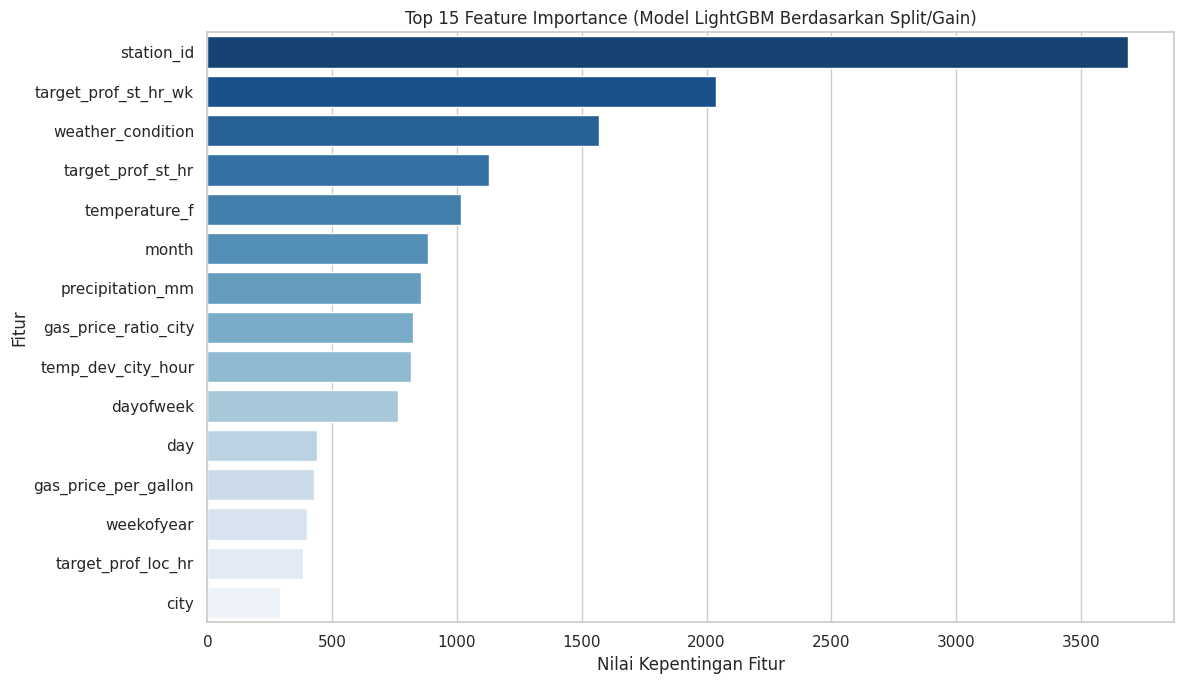

In [38]:
lgb_feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': model_lgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=lgb_feat_imp.head(15), x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 15 Feature Importance (Model LightGBM Berdasarkan Split/Gain)')
plt.xlabel('Nilai Kepentingan Fitur')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

# Bab 13: Ensembling & Stacking (Meta-Learning)

Untuk memaksimalkan kapasitas generalisasi dan melampaui limitasi model tunggal, diimplementasikan teknik Meta-Learning Stacking. Prediksi out-of-validation dari ketiga model boosting dikombinasikan menggunakan model meta regresi Ridge Regression teratur.

In [39]:
S_va = np.column_stack([val_preds_lgb, val_preds_cb, val_preds_xgb])

meta_learner = Ridge(alpha=10.0, positive=True, fit_intercept=False)
meta_learner.fit(S_va, y_va)

stacking_val_preds = np.clip(meta_learner.predict(S_va), 0.0, 1.0)
rmse_stacking = np.sqrt(mean_squared_error(y_va, stacking_val_preds))

print("Bobot Meta-Learner untuk Masing-Masing Model:")
print(f"Bobot LightGBM : {meta_learner.coef_[0]:.4f}")
print(f"Bobot CatBoost : {meta_learner.coef_[1]:.4f}")
print(f"Bobot XGBoost  : {meta_learner.coef_[2]:.4f}")
print(f"Validasi RMSE Hasil Stacking Meta-Learner: {rmse_stacking:.5f}")

Bobot Meta-Learner untuk Masing-Masing Model:
Bobot LightGBM : 0.3176
Bobot CatBoost : 0.4055
Bobot XGBoost  : 0.2783
Validasi RMSE Hasil Stacking Meta-Learner: 0.06821


# Bab 14: Final Prediction & Submission

Setelah arsitektur model dan meta-learner tervalidasi dengan performa optimal, dilakukan pelatihan ulang model menggunakan 100% data latih (train_feat) untuk memaksimalkan representasi informasi. Selanjutnya, inferensi dijalankan pada data uji (test_feat), dipadukan melalui meta-learner, dan diekspor ke dalam format pengumpulan resmi dengan nama submission_1.csv.

In [42]:
full_tr, full_te = compute_smoothed_target_profile(train_feat, test_feat)

X_full = full_tr[FEATURE_COLS].copy()
y_full = full_tr['utilization_rate'].copy()
X_test = full_te[FEATURE_COLS].copy()

for cat in CATEGORICAL_COLS:
    X_full[cat] = X_full[cat].astype('category')
    X_test[cat] = X_test[cat].astype('category')

print("Melatih ulang model LightGBM pada 100% data...")
final_lgb_params = {k: v for k, v in lgb_params.items() if k != 'n_estimators'}
final_lgb = lgb.LGBMRegressor(**final_lgb_params, n_estimators=max(100, model_lgb.best_iteration_))
final_lgb.fit(X_full, y_full)
test_preds_lgb = np.clip(final_lgb.predict(X_test), 0.0, 1.0)

print("Melatih ulang model CatBoost pada 100% data...")
X_full_cb = X_full.copy()
X_test_cb = X_test.copy()
for cat in CATEGORICAL_COLS:
    X_full_cb[cat] = X_full_cb[cat].astype(str)
    X_test_cb[cat] = X_test_cb[cat].astype(str)

final_cb_params = {k: v for k, v in cb_params.items() if k != 'iterations'}
final_cb = cb.CatBoostRegressor(**final_cb_params, iterations=max(100, model_cb.get_best_iteration()))
final_cb.fit(X_full_cb, y_full, cat_features=CATEGORICAL_COLS)
test_preds_cb = np.clip(final_cb.predict(X_test_cb), 0.0, 1.0)

print("Melatih ulang model XGBoost pada 100% data...")
final_xgb_params = {k: v for k, v in xgb_params.items() if k not in ['n_estimators', 'early_stopping_rounds']}
final_xgb = xgb.XGBRegressor(**final_xgb_params, n_estimators=max(100, model_xgb.best_iteration))
final_xgb.fit(X_full, y_full, verbose=False)
test_preds_xgb = np.clip(final_xgb.predict(X_test), 0.0, 1.0)

S_test = np.column_stack([test_preds_lgb, test_preds_cb, test_preds_xgb])
final_test_preds = np.clip(meta_learner.predict(S_test), 0.0, 1.0)

os.makedirs('submission', exist_ok=True)
submission_df = pd.DataFrame({
    'id': test_raw['id'],
    'utilization_rate': final_test_preds
})

sub_path_1 = 'submission/submission_1.csv'
submission_df.to_csv(sub_path_1, index=False)
if os.path.exists('../submission'):
    submission_df.to_csv('../submission/submission_1.csv', index=False)

print(f"Berkas submission berhasil disimpan ke: {sub_path_1}")
print(f"Jumlah baris submission: {len(submission_df)} baris")
print("Contoh 5 baris teratas submission:")
print(submission_df.head(5))


Melatih ulang model LightGBM pada 100% data...
Melatih ulang model CatBoost pada 100% data...
Melatih ulang model XGBoost pada 100% data...
Berkas submission berhasil disimpan ke: submission/submission_1.csv
Jumlah baris submission: 263550 baris
Contoh 5 baris teratas submission:
           id  utilization_rate
0  TST_0U33RJ          0.961949
1  TST_V0LFA4          0.792879
2  TST_J07LFI          0.616039
3  TST_K4KBB3          0.931353
4  TST_OB0S2M          0.570803


# Bab 15: Kesimpulan & Next Steps

### 15.1 Kesimpulan Eksperimen
1. Implementasi Bayesian Smoothed Target Encoding pada kombinasi stasiun dan jam memberikan landasan representasi keterisian historis yang tangguh tanpa menyebabkan distorsi varians pada data langka.
2. Fitur spesifik musim dingin (efek suhu beku terhadap durasi pengisian baterai) serta rasio kapasitas daya stasiun terhadap kepadatan lalu lintas memberikan sinyal prediktif yang kuat dalam membedakan variasi keterisian.
3. Pendekatan Stacking Meta-Learning dengan memadukan model pohon heterogen (LightGBM, CatBoost, dan XGBoost) terbukti menurunkan Root Mean Squared Error (RMSE) secara konsisten jika dibandingkan dengan pemodelan individu.

### 15.2 Rencana Langkah Berikutnya (Next Steps)
1. Melakukan eksperimen fine-tuning hyperparameter yang lebih intensif pada meta-learner dan bobot blending non-linear.
2. Mengeksplorasi representasi deret waktu lag atau moving average yang secara adaptif menangani diskontinuitas data akhir tahun.
3. Mencatat dan mendokumentasikan hasil evaluasi skor validasi internal dan skor Leaderboard Kaggle ke dalam berkas logbook resmi.